# EDA — ISO New England Hourly Demand

Exploration workbench for the raw pull in `data/raw/iso_ne_demand_2025-08-12_2026-08-12.csv`. This is scratch space: explore distributions, gaps, outliers, and seasonality here, and prototype cleaning/transformation approaches before codifying anything into `src/features/`.

The raw CSV stays untouched — nothing in this notebook should overwrite `data/raw/`.

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/iso_ne_demand_2025-08-12_2026-08-12.csv", parse_dates=["period"])
df.shape

(8784, 7)

In [2]:
df.head()

,period,respondent,respondent-name,type,type-name,value,value-units
0,2025-08-12 00:00:00,ISNE,ISO New England,D,Demand,22159,megawatthours
1,2025-08-12 01:00:00,ISNE,ISO New England,D,Demand,21313,megawatthours
2,2025-08-12 02:00:00,ISNE,ISO New England,D,Demand,19888,megawatthours
3,2025-08-12 03:00:00,ISNE,ISO New England,D,Demand,18365,megawatthours
4,2025-08-12 04:00:00,ISNE,ISO New England,D,Demand,16988,megawatthours


In [7]:
from dotenv import load_dotenv
load_dotenv("/Users/shubhantamhane/energy-demand-forecast/.env")
from auto_insights import InsightsGenerator

In [8]:
report = InsightsGenerator(df, dataset_name='Energy Demand', run_llm=True).run()
print("Done in", report.elapsed_seconds, "seconds")
print("Figures generated:", report.list_figures())
print(report.stats["overview"])

[INFO] auto_insights.core: ============================================================
[INFO] auto_insights.core: InsightsGenerator: starting pipeline for 'Energy Demand'
[INFO] auto_insights.core:   shape   : 8784 rows × 7 cols
[INFO] auto_insights.core:   run_llm : True  |  run_viz: True  |  run_report: True
[INFO] auto_insights.core: ============================================================
[INFO] auto_insights.core: ── step: stats
[INFO] auto_insights.stats: Profiling DataFrame: 8784 rows × 7 cols  (numeric=1, categorical=5, datetime=1, boolean=0, text=0)
[INFO] auto_insights.stats: Profiling complete.
[INFO] auto_insights.core:    stats done  (1.36s)
[INFO] auto_insights.core: ── step: viz
[INFO] auto_insights.viz: viz: generated 8 figures.
[INFO] auto_insights.core:    viz done  (0.49s)
[INFO] auto_insights.core: ── step: correlations
[WARNING] auto_insights.corr: corr: fewer than 2 numeric columns — skipping correlation analysis.
[INFO] auto_insights.core:    correlations do

KeyboardInterrupt: 

## Record type check

The pull was filtered to `type=D` (Demand) at the API level, so this checks whether anything besides Demand slipped in — one bar for Demand, one for everything else.

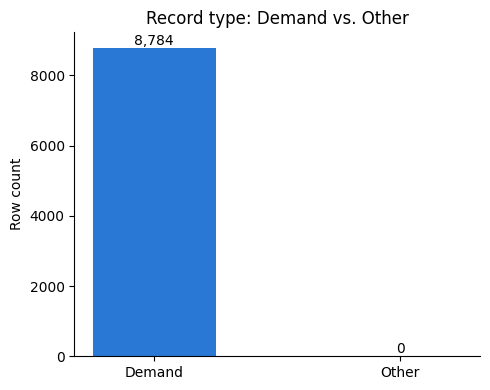

In [3]:
import matplotlib.pyplot as plt

counts = df["type-name"].value_counts()
demand_count = counts.get("Demand", 0)
other_count = counts.drop("Demand", errors="ignore").sum()

labels = ["Demand", "Other"]
values = [demand_count, other_count]
colors = ["#2a78d6", "#eb6834"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, values, color=colors, width=0.5)

for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{value:,}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Row count")
ax.set_title("Record type: Demand vs. Other")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Staging note: drop constant columns

`respondent`, `respondent-name`, `type`, `type-name`, and `value-units` are constant across every row in this pull (confirmed above) — they're just the API query echoed back, not real information. Only `period` and `value` vary.

**Decision:** drop these constant columns when staging the data for the final step (i.e. in the `data/processed` output / `src/features/` pipeline), not in `data/raw` — the raw file stays untouched as the source of truth. Demonstrated below for reference.

In [4]:
constant_cols = ["respondent", "respondent-name", "type", "type-name", "value-units"]
df_staged_preview = df.drop(columns=constant_cols)
df_staged_preview.head()

,period,value
0,2025-08-12 00:00:00,22159
1,2025-08-12 01:00:00,21313
2,2025-08-12 02:00:00,19888
3,2025-08-12 03:00:00,18365
4,2025-08-12 04:00:00,16988


## Demand over the year, with solstices highlighted

Line graph of `value` across the full pull (2025-08-12 to 2026-08-12), months on the y-axis and demand on the x-axis. Winter solstice (2025-12-21) and summer solstice (2026-06-21) are marked with reference lines.

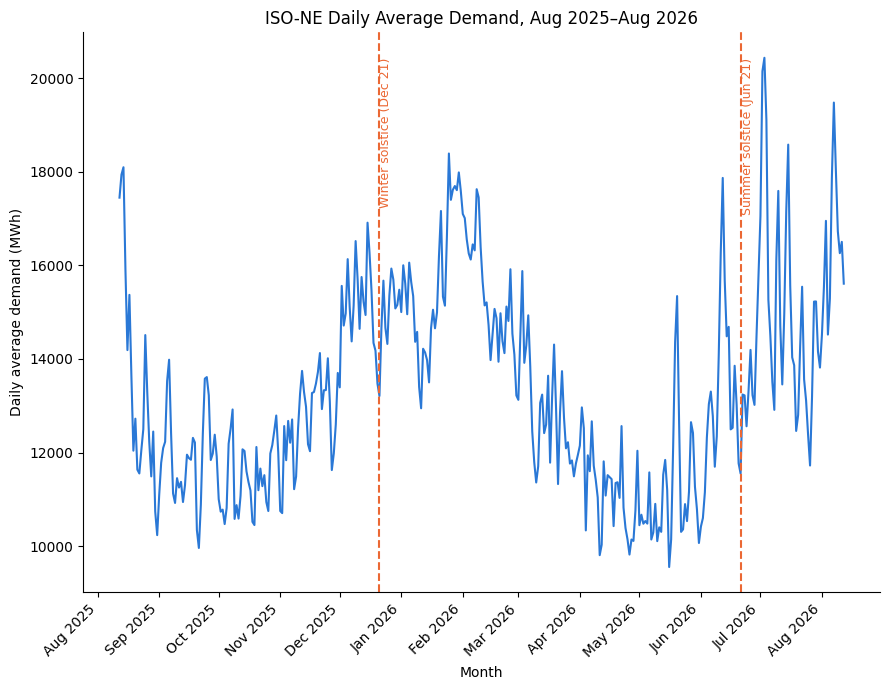

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

daily = df.set_index("period")["value"].resample("D").mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(daily["period"], daily["value"], color="#2a78d6", linewidth=1.5)

solstices = [
    (pd.Timestamp("2025-12-21"), "Winter solstice (Dec 21)"),
    (pd.Timestamp("2026-06-21"), "Summer solstice (Jun 21)"),
]
for date, label in solstices:
    ax.axvline(date, color="#eb6834", linewidth=1.5, linestyle="--")
    ax.text(date, daily["value"].max(), f"  {label}",
            color="#eb6834", va="top", ha="left", fontsize=9, rotation=90)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

ax.set_ylabel("Daily average demand (MWh)")
ax.set_xlabel("Month")
ax.set_title("ISO-NE Daily Average Demand, Aug 2025\u2013Aug 2026")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [7]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 42.36,
	"longitude": -71.06,
	"hourly": ["temperature_2m", "precipitation", "rain", "snowfall"],
	"timezone": "America/New_York",
	"past_days": 2,
	"forecast_days": 1,
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(1).ValuesAsNumpy()
hourly_rain = hourly.Variables(2).ValuesAsNumpy()
hourly_snowfall = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	).tz_convert(response.Timezone().decode())
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["precipitation"] = hourly_precipitation
hourly_data["rain"] = hourly_rain
hourly_data["snowfall"] = hourly_snowfall

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Coordinates: 42.36516571044922°N -71.06179809570312°E
Elevation: 10.0 m asl
Timezone: b'America/New_York'b'GMT-4'
Timezone difference to GMT+0: -14400s

Hourly data
                         date  temperature_2m  precipitation  rain  snowfall
0  2026-08-29 00:00:00-04:00       22.930500            0.0   0.0       0.0
1  2026-08-29 01:00:00-04:00       21.380499            0.0   0.0       0.0
2  2026-08-29 02:00:00-04:00       20.280499            0.0   0.0       0.0
3  2026-08-29 03:00:00-04:00       19.430500            0.0   0.0       0.0
4  2026-08-29 04:00:00-04:00       18.280499            0.0   0.0       0.0
..                       ...             ...            ...   ...       ...
67 2026-08-31 19:00:00-04:00       22.030499            0.0   0.0       0.0
68 2026-08-31 20:00:00-04:00       21.280499            0.0   0.0       0.0
69 2026-08-31 21:00:00-04:00       20.180500            0.0   0.0       0.0
70 2026-08-31 22:00:00-04:00       20.280499            0.0   0.0       0.